# EX06: Top-down Parsing with Recursive Descendent Parsers

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho

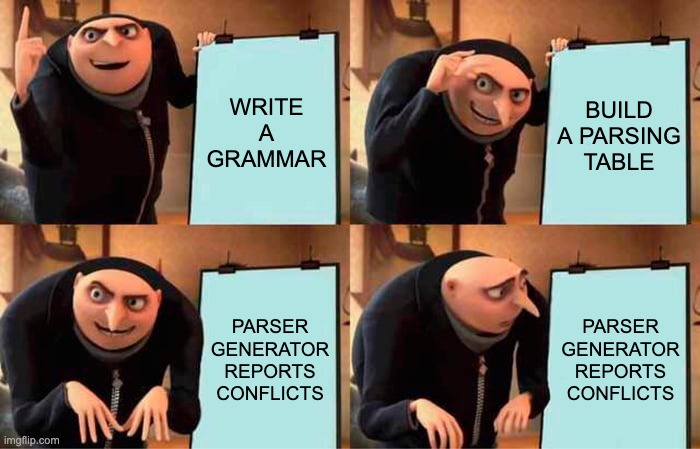

# LL(1) parsing

- An LL(1) parser is a predictive top-down parser that:
  - reads input Left-to-right
  - produces a Leftmost derivation
  - uses **1 lookahead token**

- To decide which production to apply, the parser uses **lookahead sets**

- To compute these sets we define, for each nonterminal $\mathtt{A} \in N$:
  - $\mathrm{FIRST}(\mathtt{A})$ - terminals that can appear at the beginning of strings derived from $\mathtt{A}$
  - $\mathrm{FOLLOWS}(\mathtt{A})$ - terminals that can appear immediately after
 $\mathtt{A}$

- A grammar is LL(1) if there are no conflicts between these sets, so that a predictive choice can be made at any time
  - this is the LL(1) condition

# Exercise 1

Consider the CFGs below. For each:
- Determine the FIRST and FOLLOW sets
- Test the LL(1) condition
- If the LL(1) condition does not hold, re-write into an equivalent LL(1) grammar
- Write the LL(1) parsing table

## Exercise 1.1

Σ = { `LET`, `NUM`, `ID`, `;`, `=` }, $S_0$ = `Decl`

```
p1: Decl → LET ID = NUM ;
p2:      | LET ID ;
```

## Exercise 1.2

Σ = { `INT`, `BOOL`, `ID`, `PUBLIC`, `;` }, $S_0$ = `Statement`

```
p1: Statement   → OptModifier Type ID ;
p2: OptModifier → PUBLIC
p3:             | ε
p4: Type        → INT
p5:             | BOOL
```

## Exercise 1.3

Σ = { `ID`, `NUM`, `,`, `;`, `(`, `)`, `=` }, $S_0$ = `Statement`

```
p1: Statement → ID = Expr ;
p2:           | ID ( ArgList ) ;
p3: ArgList   → Expr ArgList'
p4: ArgList'  → , Expr ArgList'
p5:           | ε
p6: Expr      → ID
p7:           | NUM
```

# Exercise 2

Consider a language to represent binary trees with integer values, such as the ones below.

- `(5 (22 () ()) (9 () (17 () ())))` ✅
- `(25 () ())` ✅
- `(57 (53 (23) ()) ())` ❌ (syntactic error)
- `(57 (53 () ()) ()` ❌ (syntactic error)

## Exercise 2.1

The CFG below, with Σ = { `(`, `)`, `INT` }, N = { `Tree`, `Value` }, $S_0$ = `Tree`, is able to generate this language.

```
p1: Tree  → ( Value Tree Tree )
p2:       | ( )
p3: Value → INT
```

However, this CFG is not LL(1). Prove it.


## Exercise 2.2

Rewrite the CFG above to an equivalent version LL(1) (i.e., generating the same language). Show that it passes the LL(1) condition.

## Exercise 2.3

Write the predictive parsing table for the LL(1) grammar.

## Exercise 2.4

Write a recursive descent parser to recognize input texts generated by this grammar.

Start by writing the lexer using `Ply.lex`.


In [ ]:
!pip install ply

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB/s eta 0:00:00


In [ ]:
import doctest

In [ ]:
def bintree(text):
  """
  >>> bintree("(25 () ())")
  Recognized!

  >>> bintree("(5 (22 () ()) (9 () (17 () ())))")
  Recognized!

  >>> bintree("()")
  Recognized!

  >>> bintree("(")
  Unexpected token when recognizing nonterminal 'Rest': $

  >>> bintree("(20)")
  Unexpected token when recognizing nonterminal 'Tree': )

  >>> bintree("(20 ())")
  Unexpected token when recognizing nonterminal 'Tree': )

  >>> bintree("(57 (53 (23) ()) ())")
  Unexpected token when recognizing nonterminal 'Tree': )

  >>> bintree("(57 (53 () ()) ()")
  Unexpected token when recognizing terminal ): $
  """
  try:
    parse(text)
    print("Recognized!")
  except Exception as e:
    print(e)

doctest.run_docstring_examples(bintree, globals())

## Exercise 2.5

Adapt the recursive descendent parser from the previous exercise to print the tree into the output.

In [ ]:
def print_bintree(text):
  r"""
  >>> print_bintree("(25 () ())")
  25
    x
    x

  >>> print_bintree("(5 (22 () ()) (9 () (17 () ())))")
  5
    22
      x
      x
    9
      x
      17
        x
        x

  >>> print_bintree("()")
  x

  >>> print_bintree("(5 (22 (13 () ()) (29 () ())) (9 () (17 (34 () ()) ())))")
  5
    22
      13
        x
        x
      29
        x
        x
    9
      x
      17
        34
          x
          x
        x
  """
  try:
    parse(text)
  except Exception as e:
    print(e)

doctest.run_docstring_examples(print_bintree, globals())

## Exercise 2.6

Add *semantic actions* to the recursive descendent parser to find the maximum value of the tree.

In [ ]:
def max_bintree(text):
  r"""
  >>> max_bintree("(25 () ())")
  25

  >>> max_bintree("(5 (22 () ()) (9 () (17 () ())))")
  22

  >>> max_bintree("()")
  None

  >>> max_bintree("(5 (22 (13 () ()) (29 () ())) (9 () (17 (34 () ()) ())))")
  34
  """
  try:
    print(parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(max_bintree, globals())

## Exercise 2.7

Add *semantic actions* to the recursive descendent parser to extract an intermediate representation of the binary tree as Python *nested tuples*. Consider the empty tree to be represented by `None`.

In [ ]:
def tuple_bintree(text):
  r"""
  >>> tuple_bintree("(25 () ())")
  (25, None, None)

  >>> tuple_bintree("(5 (22 () ()) (9 () (17 () ())))")
  (5, (22, None, None), (9, None, (17, None, None)))

  >>> tuple_bintree("()")
  None

  >>> tuple_bintree("(5 (22 (13 () ()) (29 () ())) (9 () (17 (34 () ()) ())))")
  (5, (22, (13, None, None), (29, None, None)), (9, None, (17, (34, None, None), None)))
  """
  try:
    print(parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(tuple_bintree, globals())

# Exercise 3

Consider a language to write propositional logic formulas.

- `A ∨ X ∧ ⊤ ⇒ (A ∨ ¬X)` ✅
- `A ∨ X ¬Y` ❌ (syntactic error)
- `∨ X ∧ ⊥` ❌ (syntactic error)

## Exercise 3.1

The CFG below, with Σ = { `(`, `)`, `∨`, `∧`, `⇒`, `¬`, `⊤`, `⊥`, `ID` }, N = { `Impl`, `Conj`, `Disj`, `Lit` }, $S_0$ = `Impl`, is able to generate this language.

```
p1:  Impl → Impl ⇒ Disj
p2:       | Disj
p3:  Disj → Disj ∨ Conj
p4:       | Conj
p5:  Conj → Conj ∧ Lit
p6:       | Lit
p7:  Lit  → ID  
p8:       | ⊤
p9:       | ⊥
p10:      | ¬ Lit
p11:      | ( Impl )
```

However, this CFG is not LL(1). Prove it.


## Exercise 3.2

Rewrite the CFG above to an equivalent version LL(1) (i.e., generating the same language). Show that it passes the LL(1) condition.

## Exercise 3.3

Write the predictive parsing table for the LL(1) grammar.

## Exercise 3.4

Write a recursive descent parser to recognize input texts generated by this grammar.

Start by writing the lexer using `Ply.lex`. Consider a C-like concrete syntax for the logical operators, `=>`, `||`, `&&`, `!`, and keywords for constants `true` and `false`.


In [ ]:
def propexpr(text):
  """
  >>> propexpr("A || X")
  Recognized!

  >>> propexpr("A || X && true")
  Recognized!

  >>> propexpr("X")
  Recognized!

  >>> propexpr("!(A || X) => !false")
  Recognized!

  >>> propexpr("A || X && true => (A || !X)")
  Recognized!

  >>> propexpr("A || X !Y")
  Unexpected token when recognizing nonterminal 'ConjPrime': NOT

  >>> propexpr("|| X && false")
  Unexpected token when recognizing nonterminal 'Impl': OR

  >>> propexpr("!(A || B")
  Unexpected token when recognizing terminal ): $
  """
  try:
    parse(text)
    print("Recognized!")
  except Exception as e:
    print(e)

doctest.run_docstring_examples(propexpr, globals())

## Exercise 3.5

Add *semantic actions* to the recursive descendent parser to extract an intermediate representation of the propositional expressions as Python *nested tuples*. Use the first element of the tuple to register the type of the operator.

Note: Although ∧ and ∨ are associative operators, ⇒ is not
  - ≡ `(⊥ ⇒ ⊤) ⇒ ⊥` ≡ `⊤ ⇒ ⊥` ≡ `⊥`
  - ≢ `⊥ ⇒ (⊤ ⇒ ⊥)` ≡ `⊥ ⇒ ⊥` ≡ `⊤`

The correct interpretation for `⊥ ⇒ ⊤ ⇒ ⊥` is the former, it is left-associative. For simplicity, you may associate ∧ and ∨ to the right.


In [ ]:
def tuple_propexpr(text):
  """
  >>> tuple_propexpr("true")
  ('true',)

  >>> tuple_propexpr("true || false")
  ('OR', ('true',), ('false',))

  >>> tuple_propexpr("true && false")
  ('AND', ('true',), ('false',))

  >>> tuple_propexpr("A || X")
  ('OR', ('A',), ('X',))

  >>> tuple_propexpr("A || X || false")
  ('OR', ('A',), ('OR', ('X',), ('false',)))

  >>> tuple_propexpr("A && X")
  ('AND', ('A',), ('X',))

  >>> tuple_propexpr("A || false && X")
  ('OR', ('A',), ('AND', ('false',), ('X',)))

  >>> tuple_propexpr("A || (false && X)")
  ('OR', ('A',), ('AND', ('false',), ('X',)))

  >>> tuple_propexpr("(A || true) && X ")
  ('AND', ('OR', ('A',), ('true',)), ('X',))

  >>> tuple_propexpr("!A && X")
  ('AND', ('NOT', ('A',)), ('X',))

  >>> tuple_propexpr("!(A && X)")
  ('NOT', ('AND', ('A',), ('X',)))

  >>> tuple_propexpr("false => true => false")
  ('IMPLIES', ('IMPLIES', ('false',), ('true',)), ('false',))

  >>> tuple_propexpr("(false => true) => false")
  ('IMPLIES', ('IMPLIES', ('false',), ('true',)), ('false',))

  >>> tuple_propexpr("false => (true => false)")
  ('IMPLIES', ('false',), ('IMPLIES', ('true',), ('false',)))
  """
  try:
    print(parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(tuple_propexpr, globals())

## Exercise 3.6

Assume that you are given a dictionary that assigns to each identifier in the propositional expression a value `True` or `False`. Add *semantic actions* to the recursive descendent parser to evaluate the value of an expression.

In [ ]:
def eval_propexpr(eval,text):
  """
  >>> eval_propexpr({}, "true")
  True

  >>> eval_propexpr({}, "true || false")
  True

  >>> eval_propexpr({}, "true && false")
  False

  >>> eval_propexpr({"A":True,"X":False}, "A || X")
  True

  >>> eval_propexpr({"A":True,"X":False}, "A || X || false")
  True

  >>> eval_propexpr({"A":True,"X":False}, "A && X")
  False

  >>> eval_propexpr({"A":False,"X":True}, "A || false && X")
  False

  >>> eval_propexpr({"A":False,"X":True}, "A || (false && X)")
  False

  >>> eval_propexpr({"A":False,"X":True}, "(A || true) && X ")
  True

  >>> eval_propexpr({"A":True,"X":False}, "!A && X")
  False

  >>> eval_propexpr({"A":True,"X":False}, "!(A && X)")
  True

  >>> eval_propexpr({}, "false => true => false")
  False

  """
  try:
    print(parse(eval,text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(eval_propexpr, globals())

-- Nuno Macedo, 2026-04-07